In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Находим корень проекта (поднимаемся на уровень выше папки notebooks)
root = Path.cwd().parent
sys.path.append(str(root))
sys.path.append(r"/trinity/home/asma.benachour/BrainBERT")


from utils.analysis_pipeline import (
    load_and_preprocess,
    create_epochs,
    save_epochs,
    plot_epochs_images,
)
from utils.config import ch_to_keep, best_ch_by_power
import models
import torch
from omegaconf import OmegaConf

%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats


import mne

# from mne_bids import (
#     BIDSPath,
#     find_matching_paths,
#     get_entity_vals,
#     read_raw_bids,
# )

from scipy.signal import stft
from intervaltree import Interval, IntervalTree
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from mne.filter import notch_filter
from scipy.signal import welch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, make_scorer
import numpy as np

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

	
import abc
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.model_selection import cross_val_predict

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, f1_score
import numpy as np

import yaml

from utils.normalisation import normalize_tfr_robust

In [ ]:
subject = "s10"

In [ ]:
to_patients_yaml = {
    "root": "/beegfs/home/asma.benachour/notebooks/Pirogov/MNE_playground/notebooks",
    "s10": {
        "time_frequency_file": "../tfr_s10.fif",
        "min_f": 5, 
        "max_f": 30, 
        "min_t": 100, 
        "max_t": -500
    },
    "s11": {
        "time_frequency_file": "../tfr_s11.fif",
        "min_f": 0, 
        "max_f": 10, 
        "min_t": 100, 
        "max_t": -400
    },
}

with open('../patients.yaml', 'w') as f:
    yaml.dump(to_patients_yaml, f)

In [3]:
tfr = mne.time_frequency.read_tfrs(f"../tfr_{subject}.fif")[0]

Reading ../tfr_s10.fif ...


/tmp/ipykernel_1098760/2683822843.py:1: RuntimeWarning: This filename (../tfr_s10.fif) does not conform to MNE naming conventions. All tfr files should end with -tfr.h5 or _tfr.h5
  tfr = mne.time_frequency.read_tfrs("../tfr_s10.fif")[0]


Not setting metadata


In [4]:
channel = "Fp1"

In [5]:
y = np.where(tfr.events[:, 2] == 9, 1, 0)

In [13]:
# X = normalize_tfr_robust(tfr.copy().crop(tmin=0.0, tmax=1.0).data)[:, :, :10, 100:-400]
# X = normalize_tfr_robust(tfr.copy().crop(tmin=0.0, tmax=1.0).data)[:, :, 5:30, 100:-500]
X = normalize_tfr_robust(tfr.copy().crop(tmin=0.0, tmax=1.0).data)[:, :, 5:30, 100:-500]

# Check

In [7]:
X_1=X[np.where(y==1)[0],:,:,:]
X_0=X[np.where(y==0)[0],:,:,:]

first=X_1.reshape(X_1.shape[0], -1)
zero=X_0.reshape(X_0.shape[0], -1)

# plt.plot(first.T)
# plt.ylim(-0.2,1.3)

# plt.plot(zero.T)
# plt.ylim(-0.2,1.3)
# plt.show()

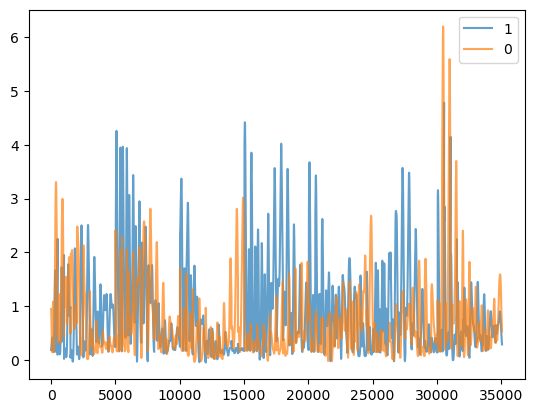

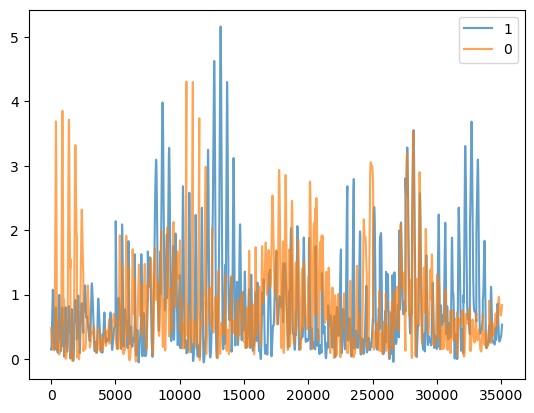

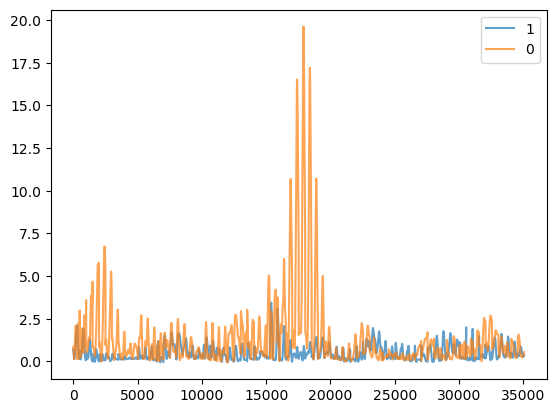

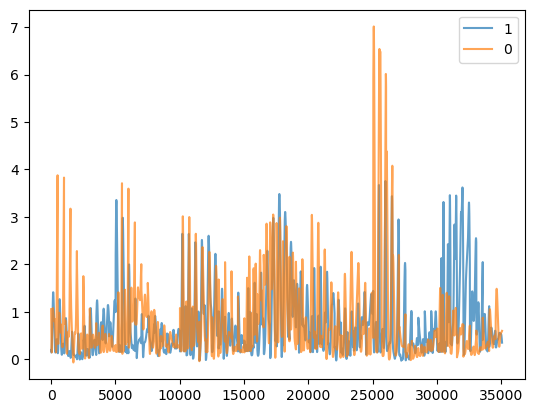

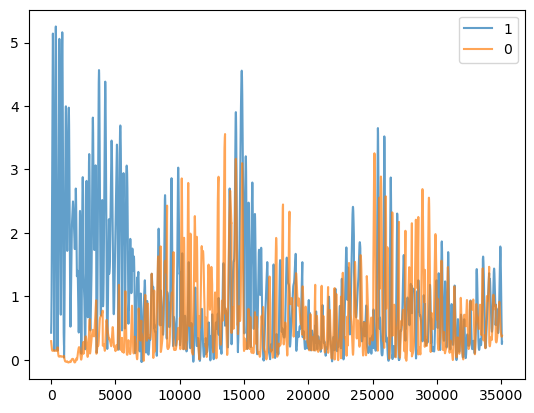

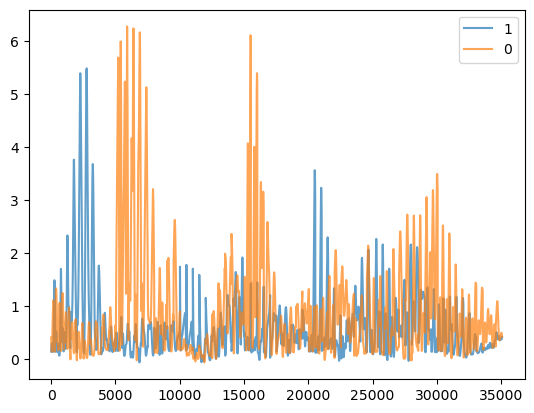

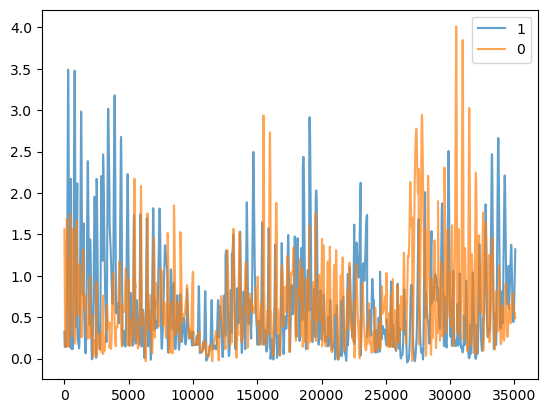

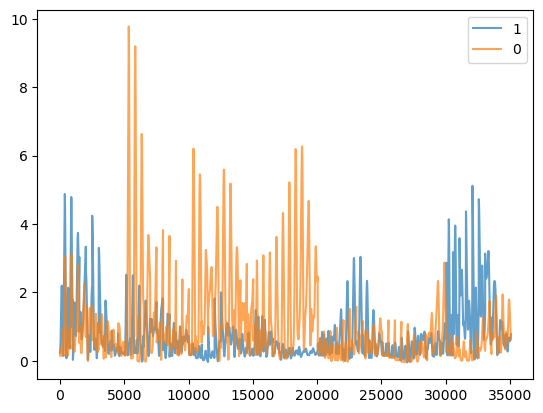

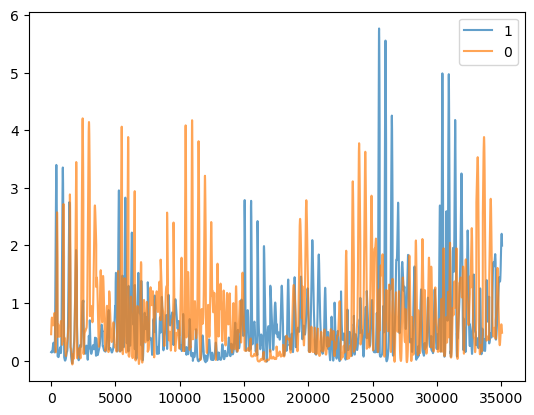

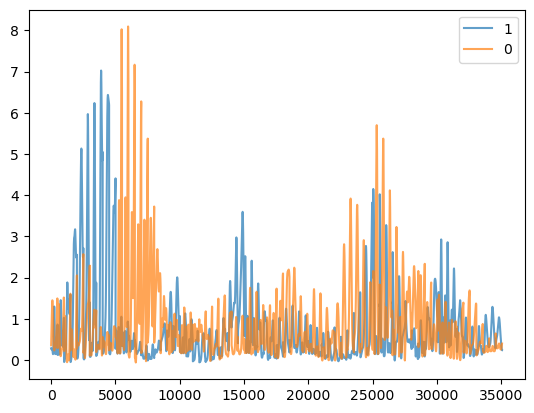

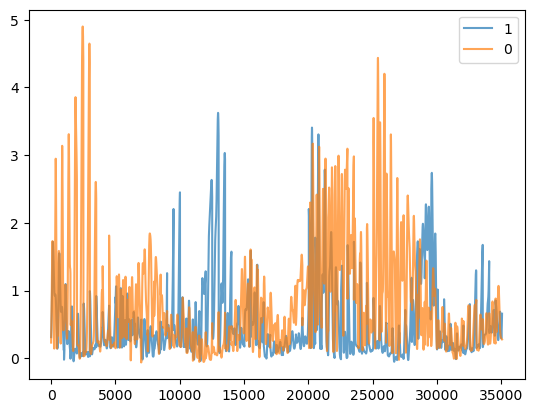

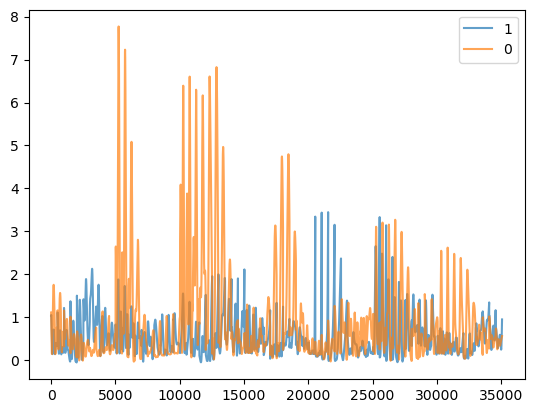

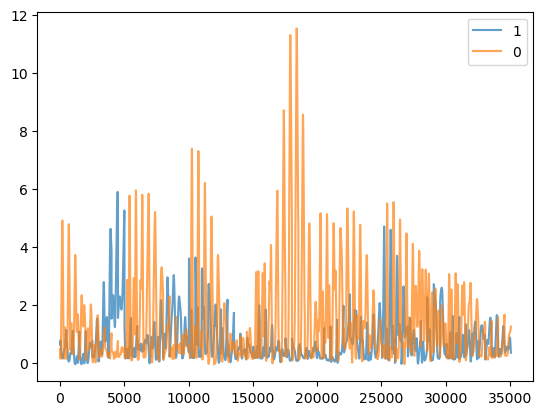

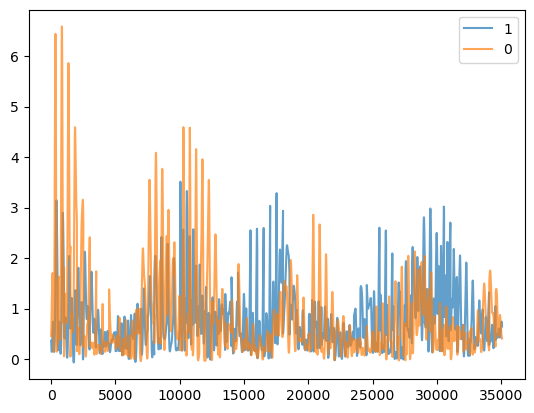

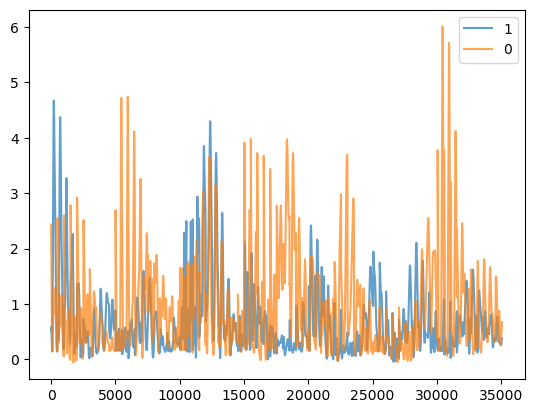

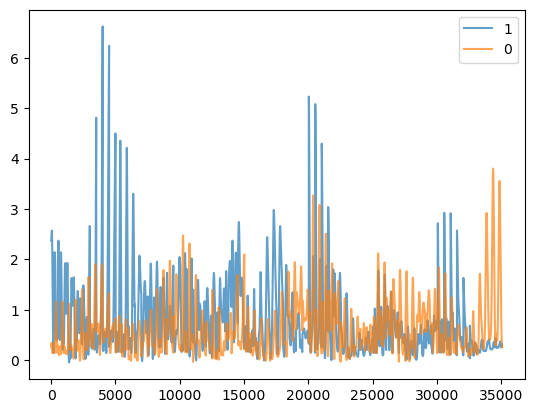

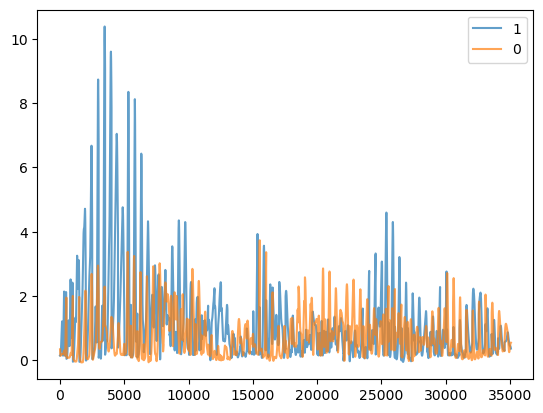

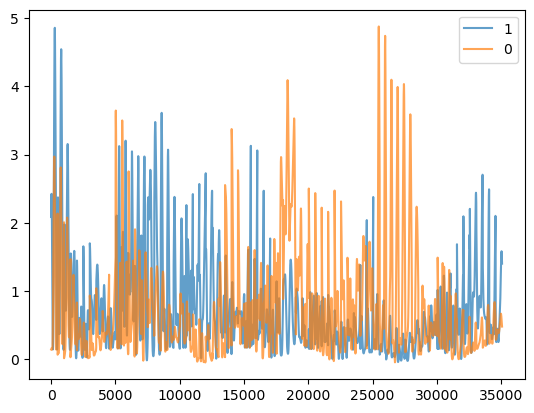

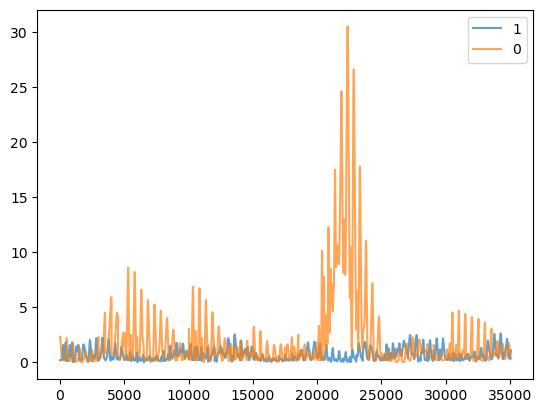

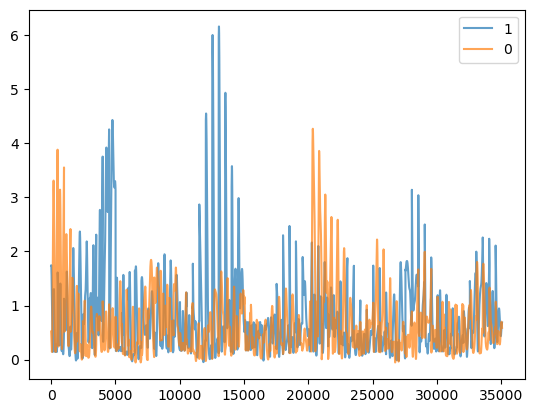

In [8]:
for i in range(20):
    plt.plot(first[i], alpha=0.7, label='1')
    plt.plot(zero[i], alpha=0.7, label='0')
    plt.legend()
    plt.show()

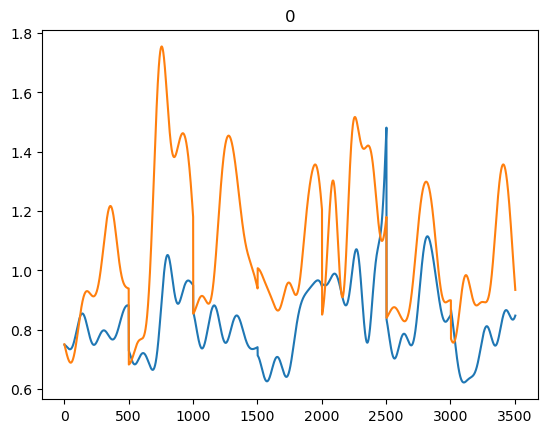

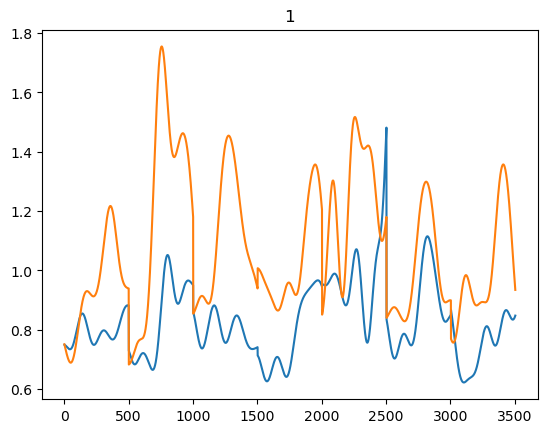

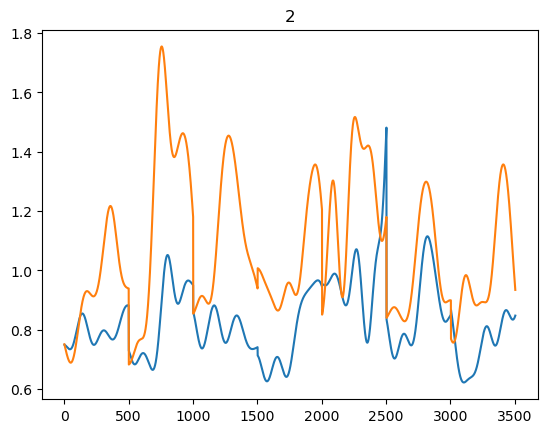

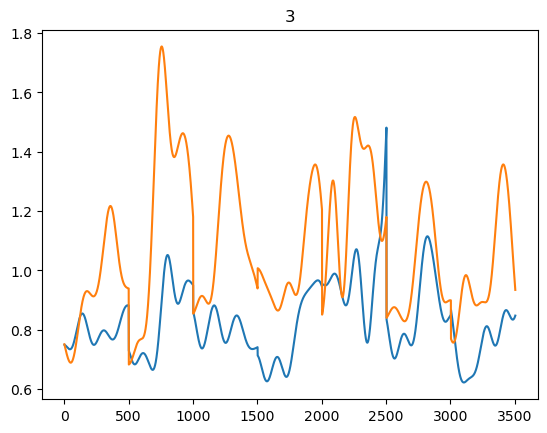

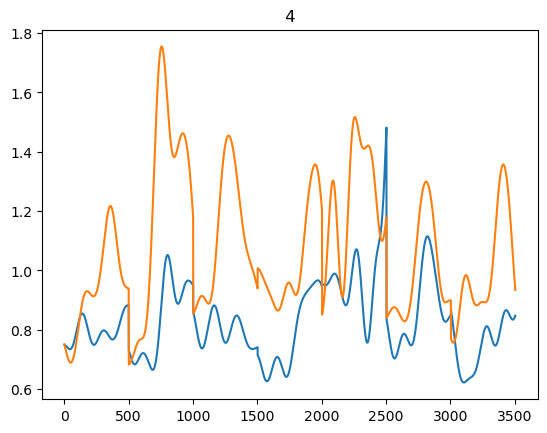

In [ ]:
for i in range(5):
    plt.title(i)
    X_1=X[np.where(y==1)[0],:,i,:]
    X_0=X[np.where(y==0)[0],:,i,:]

    plt.title(i)
    first=np.mean( X_1.reshape(X_1.shape[0], -1), 0)
    zero=np.mean( X_0.reshape(X_0.shape[0], -1) , 0)
    
    plt.plot(first.T)
    
    plt.plot(zero.T)
    plt.show()

In [ ]:
X_1=X[np.where(y==1)[0],-1,:10,100:-400]
X_0=X[np.where(y==0)[0],-1,:10,100:-400]

first=X_1.reshape(X_1.shape[0], -1)
zero=X_0.reshape(X_0.shape[0], -1)

X_=X[:,:,69:75,100:-300]

st_=np.vstack([zero, first])
st_=X_.reshape(X_.shape[0], -1)
pca=PCA(0.95)
out=pca.fit_transform(st_)
print( np.sum(pca.explained_variance_ratio_) )
print( pca.explained_variance_ratio_ )

In [ ]:
x_axis = out[:, 0]
y_axis = out[:, 1]
color = y

plt.figure(figsize=(7, 5))
plt.scatter(x_axis, y_axis, c=color)
plt.colorbar(label='Color scale')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Colored Scatter Plot")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score



# Split
X_train, X_test, y_train, y_test = train_test_split(
    out, y, test_size=0.2, random_state=42
)

# SVM pipeline with scaling
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf'))
])

clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Class

In [51]:
dim = X.shape
X = np.reshape(X, (dim[0], dim[1]*dim[2]*dim[3]))

In [9]:
models_grid = {
    # "FeedForward": {
    #     "model": ff,
    #     "param_grid": {
    #         "hidden_dim": [256, 512],
    #         "num_layers": [1, 2],
    #         "activation": ["ReLU", "LeakyReLU"],
    #         "dropout":[0.1, 0.2],
    #         "batchnorm": [True]
    #     }
    # },

    "SVC": {
        "model": SVC(probability=True),
        "param_grid": {
            "C": [1, 50],
            "gamma": ["scale", "auto"],
            "kernel": ["rbf"]
        },
        # "param_grid":{"C": [200], "gamma": ["scale"], "kernel": ["rbf"]}
    },

    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 200, 300],
            "max_depth": [5, 10, 15, 20]
        }
    },

    "LogisticRegression": {
        "model": LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=5000),
        "param_grid": {
            "C": [1, 50, 100],
            "penalty": ["l1", "l2"]
        }
    },

    "GradientBoosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "param_grid": {
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_leaf_nodes": [15, 31]
        }
    },

    "KNN": {
        "model": KNeighborsClassifier(),
        "param_grid": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        }
    },

    "DecisionTree": {
        "model": DecisionTreeClassifier(random_state=42),
        "param_grid": {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    }
}


In [10]:
# Кросс-валидация: одна и та же для всех моделей
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Скоринги: явно говорим, чем считать
scoring = {
    "accuracy": "accuracy",  # внутри использует accuracy_score
    "f1_macro": make_scorer(f1_score, average="macro")
}

# У каких моделей нужен скейлер
scale_models = {"SVC", "LogisticRegression", "KNN"}

results = {}

for model_name, model_config in models_grid.items():
    model = model_config["model"]
    param_grid = model_config["param_grid"]

    # --- собираем Pipeline ---
    steps = []
    if model_name in scale_models:
        steps.append(("scaler", StandardScaler()))

    # PCA для всех (fit только на train каждого фолда)
    steps.append(("pca", PCA(n_components=0.95, random_state=42)))

    steps.append(("model", model))
    pipeline = Pipeline(steps)

    # --- приводим param_grid к виду model__param ---
    param_grid_full = {f"model__{k}": v for k, v in param_grid.items()}

    print(f"\n▶ GridSearchCV for {model_name}")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_full,
        scoring=scoring,
        refit="f1_macro",        # лучшая модель по F1_macro
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    # Обучение + внутренняя КВ
    grid_search.fit(flat, y)

    # Индекс лучшей конфигурации
    best_idx = grid_search.best_index_
    cv_res = grid_search.cv_results_

    # Усреднённые по фолдам метрики для лучшего набора параметров
    acc_mean = cv_res["mean_test_accuracy"][best_idx]
    acc_std  = cv_res["std_test_accuracy"][best_idx]
    f1_mean  = cv_res["mean_test_f1_macro"][best_idx]
    f1_std   = cv_res["std_test_f1_macro"][best_idx]

    results[model_name] = {
        "best_params": grid_search.best_params_,
        "cv_accuracy_mean": acc_mean,
        "cv_accuracy_std": acc_std,
        "cv_f1_macro_mean": f1_mean,
        "cv_f1_macro_std": f1_std,
    }

    print(f"◆ {model_name}")
    print(f"   CV ACC: {cv_res['cv_accuracy_mean']:.3f} ± {cv_res['cv_accuracy_std']:.3f}")
    print(f"   CV F1 : {cv_res['cv_f1_macro_mean']:.3f} ± {cv_res['cv_f1_macro_std']:.3f}")
    print(f"   Best params: {cv_res['best_params']}")
    print()


# --- красивый вывод ---
print("\n================ Cross-Validation Summary ================\n")
for name, res in results.items():
    print(f"◆ {name}")
    print(f"   CV ACC: {res['cv_accuracy_mean']:.3f} ± {res['cv_accuracy_std']:.3f}")
    print(f"   CV F1 : {res['cv_f1_macro_mean']:.3f} ± {res['cv_f1_macro_std']:.3f}")
    print(f"   Best params: {res['best_params']}")
    print()


▶ GridSearchCV for SVC
Fitting 5 folds for each of 4 candidates, totalling 20 fits


# Polygon

# Basement

In [ ]:
class FeedforwardClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_layers=1,
        dropout=0.3,
        activation='ReLU',
        batchnorm=False,
        weight_init='xavier'
    ):
        # Странно, обычно делают так super(self).__init__()
        super(FeedforwardClassifier, self).__init__()

         # --- активация ---
        if isinstance(activation, str):
            if not hasattr(nn, activation):
                raise ValueError(f"Unknown activation '{activation}' in torch.nn")
            self.activation_cls = getattr(nn, activation)
            self._nonlinearity_name = activation.lower()
        elif isinstance(activation, type) and issubclass(activation, nn.Module):
            self.activation_cls = activation
            self._nonlinearity_name = 'relu'  # разумная дефолтная подсказка для kaiming
        else:
            raise TypeError("activation must be a str (e.g., 'ReLU') or an nn.Module class (e.g., nn.ReLU)")

        self.batchnorm = batchnorm
        self.dropout = dropout
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        layers = []
        in_dim = input_dim

        for i in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            if batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(self.activation_cls())
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_dim, output_dim)


    def forward(self, x, return_hidden=False):
        hidden = self.hidden_layers(x)
        out = self.output_layer(hidden)
        return (out, hidden) if return_hidden else out


class CNN_with_DeepMLP(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        # 🔥 CNN остаётся точно тем, какой был!
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        # ⬇️ Размер выхода CNN после AdaptiveAvgPool2d = (64, 4, 4)
        cnn_output_dim = 64 * 4 * 4

        # 🔥 Подключаем твой большой MLP:
        self.mlp = DeepMLP(
            input_dim=cnn_output_dim,
            hidden_dim=1024,
            num_layers=50,
            num_classes=num_classes,
        )

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)  # (batch, 64*4*4)
        x = self.mlp(x)
        return x


class TFRDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
def average_losses(all_train, all_val):
    # Превращаем список фолдов в маску (folds x epochs)
    train_mat = np.array(all_train)
    val_mat = np.array(all_val)

    # Среднее и std по фолдам: axis=0
    mean_train = train_mat.mean(axis=0)
    std_train = train_mat.std(axis=0)

    mean_val = val_mat.mean(axis=0)
    std_val = val_mat.std(axis=0)

    return mean_train, std_train, mean_val, std_val

In [ ]:
def plot_loss(mean_train, std_train, mean_val, std_val):
    import matplotlib.pyplot as plt

    epochs = np.arange(1, len(mean_train) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, mean_train, label="Train Loss")
    plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.2)

    plt.plot(epochs, mean_val, label="Val Loss")
    plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
plt.plot(y_test)
plt.plot(y_pred)
plt.show()
plt.plot(y_test-y_pred)y.shape
X[y == 0].shape
plt.imshow(np.mean(X[y == 0], axis=(0))[0])
plt.show()
plt.imshow(np.mean(X[y == 1], axis=(0))[0])
plt.show()
class model_wrappers(abc.ABC):
    def flattening (X):
        dim = X.shape
        if len(dim) != 4:
            raise Exception("Dimentionality of X must be (trials, channels, freqs, times)")        
        flat = np.reshape(X, (dim[0], dim[2]*dim[3] ), order='F')
        return flat

    def neural_net_fit_scaffold(self, model, epochs, train_loader, val_loader, optimizer, criterion, device):
        train_losses = []
        val_losses = []

        for epoch in range(epochs):
            model.train()
            running_loss = 0

            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device).unsqueeze(1)

                optimizer.zero_grad()
                out = model(Xb)
                loss = criterion(out, yb)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            train_losses.append(running_loss / len(train_loader))

            # validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb, yb = Xb.to(device), yb.to(device).unsqueeze(1)
                    out = model(Xb)
                    loss = criterion(out, yb)
                    val_loss += loss.item()

            val_losses.append(val_loss / len(val_loader))

            print(
                f"  Epoch {epoch+1}/{epochs}  TrainLoss={train_losses[-1]:.4f}  ValLoss={val_losses[-1]:.4f}"
            )

        return train_losses, val_losses
    
    def neural_net_predict_scaffold(self, model, val_loader, device):            
        # теперь метрики
        model.eval()
        preds = []

        with torch.no_grad():
            for Xb, _ in val_loader:
                Xb = Xb.to(device)
                out = model(Xb)
                p = torch.sigmoid(out).cpu().numpy().ravel()
                preds.extend(p)

        preds_bin = (np.array(preds) >= 0.5).astype(int)
        
        return preds_bin


    @abc.abstractmethod 
    def fit():
        "impl"

    @abc.abstractmethod 
    def predict():
        "impl"

class MLP_model_wrapper(model_wrappers):
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # модель
        # self.model = DeepMLP().to(self.device)

    def set_params(self, input_dim=200, hidden_dim=256, output_dim=1, num_layers=1, activation='ReLU', dropout=0.3, batchnorm=False):
        self.model = FeedforwardClassifier(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            num_layers=num_layers,
            activation=activation,
            dropout=dropout,
            batchnorm=batchnorm
        ).to(self.device)

    def fit(self, train_loader, val_loader, epochs, lr, device = None, model = None):
        if device is None:
            device = self.device
        if model is None:
            model = self.model

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()

        train_losses, val_losses = super().neural_net_fit_scaffold(model, epochs, train_loader, val_loader, optimizer, criterion, device)
        
        return train_losses, val_losses

    def predict(self, val_loader, device = None, model = None):
        if device is None:
            device = self.device
        if model is None:
            model = self.model
        preds = super().neural_net_predict_scaffold(model, val_loader, device)
        
        return preds
def run_cv_classic(X, y, model_wrapper, param, epochs=15, lr=1e-3, batch_size=32, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    
    acc_list, f1_list = [], []
    all_train_losses = []
    all_val_losses = []

    Flat_X = model_wrappers.flattening(X)
    pca = PCA(n_components=0.95)
    Flat_X = pca.fit_transform(X_flat)
    

    for fold, (train_idx, test_idx) in enumerate(skf.split(Flat_X, y)):
        print(f"\n===== Fold {fold+1}/{folds} =====")

        initialised_model = model_wrapper.set_params(**param)

        X_train, X_test = Flat_X[train_idx], Flat_X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        initialised_model.fit(X_train, y_train)
        preds_bin = initialised_model.predict(X_test)

        acc = accuracy_score(y_test, preds_bin)
        f1 = f1_score(y_test, preds_bin)

        acc_list.append(acc)
        f1_list.append(f1)

        print(f"Fold {fold+1}: ACC={acc:.3f}, F1={f1:.3f}")

    print("\n======= FINAL =======")
    print(f"ACC = {np.mean(acc_list):.3f} ± {np.std(acc_list):.3f}")
    print(f"F1  = {np.mean(f1_list):.3f} ± {np.std(f1_list):.3f}")

    return all_train_losses, all_val_losses, y_test, preds_bin, acc_list, f1_list

def run_cv_neural(X, y, model_wrapper, param, epochs=15, lr=1e-3, batch_size=32, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    acc_list, f1_list = [], []
    all_train_losses = []
    all_val_losses = []

    Flat_X = model_wrappers.flattening(X)
    pca = PCA(n_components=0.95)
    Flat_X = pca.fit_transform(X_flat)
    param["input_dim"] = Flat_X.shape[-1]

    for fold, (train_idx, test_idx) in enumerate(skf.split(Flat_X, y)):
        print(f"\n===== Fold {fold+1}/{folds} =====")

        model_wrapper.set_params(**param)

        X_train, X_test = Flat_X[train_idx], Flat_X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # PyTorch datasets
        train_ds = TFRDataset(X_train, y_train)
        val_ds = TFRDataset(X_test, y_test)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        train_losses, val_losses = model_wrapper.fit(
            train_loader, val_loader, epochs=epochs, lr=lr
        )

        all_train_losses.append(train_losses)
        all_val_losses.append(val_losses)

        preds_bin = model_wrapper.predict(val_loader)

        acc = accuracy_score(y_test, preds_bin)
        f1 = f1_score(y_test, preds_bin)

        acc_list.append(acc)
        f1_list.append(f1)

        print(f"Fold {fold+1}: ACC={acc:.3f}, F1={f1:.3f}")

    print("\n======= FINAL =======")
    print(f"ACC = {np.mean(acc_list):.3f} ± {np.std(acc_list):.3f}")
    print(f"F1  = {np.mean(f1_list):.3f} ± {np.std(f1_list):.3f}")

    return all_train_losses, all_val_losses, y_test, preds_bin, acc_list, f1_list
param ={"C": 200, "gamma": "scale", "kernel": "rbf"} 
model_wrapper = svm.SVC(probability=True)

train_losses, val_losses, y_test, preds_bin, acc_list, f1_list = run_cv_classic(
    X, y, model_wrapper, param, epochs=30, lr=1e-10, batch_size=100, folds=5
)
param ={"input_dim": 0,"hidden_dim": 512,"num_layers": 50,"activation": "ReLU","dropout":0.1,"batchnorm": True} 
model_wrapper = MLP_model_wrapper()

train_losses, val_losses, y_test, preds_bin, acc_list, f1_list = run_cv_neural(
    X, y, model_wrapper, param, epochs=30, lr=1e-10, batch_size=100, folds=5
)
mean_train, std_train, mean_val, std_val = average_losses(train_losses, val_losses)
plot_loss(mean_train, std_train, mean_val, std_val)

In [ ]:
# epochs_1 = create_epochs(files_list, sub, event_id=events_avg)[0]
# epochs_2 = create_epochs(files_list, sub, event_id=event_single)[0]
# epochs = create_epochs(files_list, sub, event_id=[*events_avg, *event_single])[0]

# for i, (epochs_avg, epochs_9) in enumerate(zip(epochs_1, epochs_2)):
#     print(f"-------------\Recording # {i+1}\n-------------")

#     # print(f"-------------\nPrinting flextions\n-------------")
#     # plot_epochs_images(epochs_avg)
#     # print(f"-------------\nPrinting relaxations\n-------------")
#     # plot_epochs_images(epochs_9)

#     print(f"-------------\nComputing TFR\n-------------")

#     freqs = np.linspace(0.1, 100, 50)
#     n_cycles = freqs / 2.

#     power_avg = mne.time_frequency.tfr_morlet(
#         epochs_avg, freqs=freqs, n_cycles=n_cycles,
#         return_itc=False, decim=2, average=True
#     )

#     power_9 = mne.time_frequency.tfr_morlet(
#         epochs_9, freqs=freqs, n_cycles=n_cycles,
#         return_itc=False, decim=2, average=True
#     )

#     baseline = (-0.2, 0)
#     p_avg = power_avg.copy().apply_baseline(baseline, mode='logratio')
#     p_9   = power_9.copy().apply_baseline(baseline, mode='logratio')

#     Da = p_avg.data
#     D9 = p_9.data
#     vmin, vmax = np.nanpercentile(np.concatenate([Da.ravel(), D9.ravel()]), [2, 98])

#     channels = epochs_avg.ch_names
#     times = p_avg.times
#     freqs = p_avg.freqs
#     extent = [times[0], times[-1], freqs[0], freqs[-1]]

#     # ---- АККУРАТНАЯ ВЕРСТКА ----
#     fig = plt.figure(figsize=(10, 3*len(channels)))
#     gs = fig.add_gridspec(len(channels), 3, width_ratios=[1, 1, 0.05], wspace=0.3)

#     for i, ch in enumerate(channels):
#         idx = p_avg.ch_names.index(ch)

#         ax_left = fig.add_subplot(gs[i, 0])
#         ax_right = fig.add_subplot(gs[i, 1])

#         im = ax_left.imshow(Da[idx], aspect='auto', origin='lower', extent=extent,
#                             vmin=vmin, vmax=vmax)
#         ax_left.set_title("Mean(1–8,10)")
#         ax_left.set_ylabel(ch)
#         ax_left.axvline(0, linestyle='--', color='white', linewidth=0.7)

#         ax_right.imshow(D9[idx], aspect='auto', origin='lower', extent=extent,
#                         vmin=vmin, vmax=vmax)
#         ax_right.set_title("Event 9")
#         ax_right.axvline(0, linestyle='--', color='white', linewidth=0.7)

#     # отдельная колонка для цветовой шкалы
#     cax = fig.add_subplot(gs[:, 2])
#     cbar = fig.colorbar(im, cax=cax)
#     cbar.set_label("Power (log-ratio)")

#     plt.tight_layout()
#     plt.show()

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(skf.split(X, y))

In [ ]:
X_train, X_test = X[train_idx], X[test_idx]
# y_train, y_test = y[train_idx], y[test_idx]

# нормализация
# X_train, X_test = normalize_train_test(X_train_before, X_test_before)

In [ ]:
plt.imshow(X_test[2, 0])
plt.show()

In [ ]:
# class CNN_MLP_model_wrapper(model_wrappers):
#     def __init__(self):
#         self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#         # модель
#         self.model = CNN_with_DeepMLP().to(self.device)

#     def fit(self, train_loader, val_loader, epochs, lr, device = None, model = None):
#         if device is None:
#             device = self.device
#         if model is None:
#             model = self.model

#         optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#         criterion = nn.BCEWithLogitsLoss()

#         train_losses, val_losses = super().neural_net_fit_scaffold(model, epochs, train_loader, val_loader, optimiser, criterion, device)
        
#         return train_losses, val_losses

#     def predict(self, val_loader, model = None):
#         if model is None:
#             model = self.model
#         preds = super().neural_net_predict_scaffold(model, val_loader, device)
        
#         return preds

In [ ]:
# X[74,1,0,:501] == flat [74, 19*501+501:20*501+501]